# Machine Learning Clássico — Notebook Teórico e Prático

## 1. Visão geral: o que é Machine Learning?

**Machine Learning (ML)** é uma área da Inteligência Artificial que busca construir modelos capazes de **aprender padrões a partir de dados**.

Em vez de programarmos explicitamente todas as regras, fornecemos exemplos e o algoritmo aprende uma função ou estrutura a partir deles.

### Perguntas típicas em ML
- **Regressão:** "Quanto?"
- **Classificação:** "Qual classe?"
- **Agrupamento:** "Quais elementos são parecidos entre si?"

### Paradigmas principais
- **Aprendizado supervisionado**: existe uma variável alvo (`y`) conhecida.
- **Aprendizado não supervisionado**: não existe variável alvo; o objetivo é descobrir estruturas ocultas nos dados.

## 2. Mapa mental resumido

### Aprendizado supervisionado
Usa pares de entrada e saída:
- `X` = atributos (features)
- `y` = alvo (target)

Subdivide-se em:
- **Regressão** → saída numérica contínua
- **Classificação** → saída categórica

### Aprendizado não supervisionado
Usa apenas os atributos `X`, sem rótulos:
- **Agrupamento (clustering)** → busca padrões e grupos naturais nos dados

## 3. Importando bibliotecas

Neste notebook usaremos `pandas`, `numpy`, `matplotlib` e `scikit-learn`.

In [43]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    silhouette_score
)

plt.rcParams["figure.figsize"] = (8, 5)

# Parte I — Regressão

## 4. O que é regressão?

Regressão é uma tarefa de aprendizado supervisionado cujo objetivo é **prever um valor numérico contínuo**.

### Exemplos
- prever preço de uma casa;
- prever temperatura;
- prever faturamento;
- prever consumo de energia.

### Ideia central
O modelo tenta aprender uma relação do tipo:

$$
y = f(X)
$$

onde:
- `X` representa as variáveis de entrada;
- `y` representa a variável numérica que queremos prever.

## 5. Exemplo intuitivo de regressão

Imagine que queremos prever o preço de uma casa com base em sua metragem.

- Casa com 50 m² → preço menor
- Casa com 150 m² → preço maior

A regressão busca aprender esse padrão.

### Saída da regressão
A saída é um número:
- R$ 250.000
- 32,5 °C
- 1.230 unidades vendidas

## 6. Métricas de regressão

As métricas mais comuns são:

### MAE — Mean Absolute Error
Erro absoluto médio:

$$
MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

### MSE — Mean Squared Error
Erro quadrático médio:

$$
MSE = \frac{1}{n}\sum (y_i - \hat{y}_i)^2
$$

### RMSE
Raiz do MSE, na mesma unidade da variável alvo.

### R²
Indica o quanto o modelo consegue explicar a variabilidade dos dados.
- próximo de 1 → melhor ajuste
- próximo de 0 → fraco

## 7. Exemplo prático de regressão

Vamos usar um dataset sintético para aprender uma regressão linear simples.

In [34]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# Gerando dados sintéticos
X_reg, y_reg = make_regression(
    n_samples=200,
    n_features=1,
    noise=15,
    random_state=42
)

# Separando treino e teste
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Treinando o modelo
reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)

# Previsões
y_reg_pred = reg_model.predict(X_reg_test)

# Métricas
mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 12.03
MSE : 246.12
RMSE: 15.69
R²  : 0.9681


## 8. Visualizando a regressão

No gráfico abaixo:
- os pontos representam os dados reais;
- a reta representa a função aprendida pelo modelo.

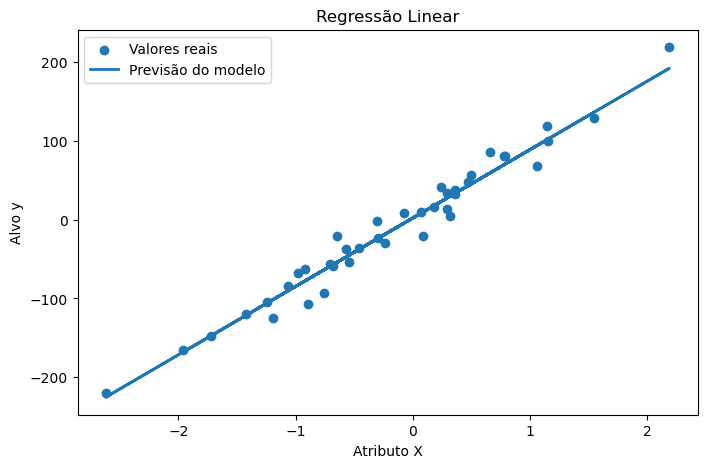

In [35]:
plt.scatter(X_reg_test, y_reg_test, label="Valores reais")
plt.plot(X_reg_test, y_reg_pred, linewidth=2, label="Previsão do modelo")
plt.xlabel("Atributo X")
plt.ylabel("Alvo y")
plt.title("Regressão Linear")
plt.legend()
plt.show()

## 9. Interpretação do exemplo de regressão

### O que o modelo fez?
Ele ajustou uma reta aos dados, tentando minimizar o erro entre valores reais e previstos.

### Quando usar regressão?
Quando a saída esperada for um valor numérico contínuo.

### Modelos clássicos de regressão
- Regressão Linear
- Regressão Polinomial
- Decision Tree Regressor
- Random Forest Regressor

# Parte II — Classificação

## 10. O que é classificação?

Classificação é uma tarefa supervisionada cujo objetivo é **atribuir uma classe a cada exemplo**.

### Exemplos
- e-mail é spam ou não spam;
- paciente tem doença ou não;
- imagem contém gato, cachorro ou pássaro.

### Tipos de classificação
- **Binária**: 2 classes
- **Multiclasse**: mais de 2 classes
- **Multirrótulo**: mais de um rótulo por exemplo

## 11. Intuição da classificação

Na classificação, o modelo aprende **fronteiras de decisão**.

Exemplo:
- `Classe 0`: não tem doença
- `Classe 1`: tem doença

Com base nos atributos de entrada, o modelo decide em qual região o exemplo pertence.

## 12. Métricas de classificação

### Acurácia
Proporção de acertos.

\[
Accuracy = \frac{Acertos}{Total}
\]

### Precisão
Entre os casos previstos como positivos, quantos realmente eram positivos.

### Recall
Entre os positivos reais, quantos o modelo encontrou.

### F1-score
Média harmônica entre precisão e recall.

### Matriz de confusão
Mostra:
- verdadeiros positivos;
- falsos positivos;
- verdadeiros negativos;
- falsos negativos.

## 13. Exemplo prático de classificação

Vamos usar o dataset `Breast Cancer` do `scikit-learn`, muito comum em exemplos didáticos de classificação binária.

In [36]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()

X_clf = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_clf = pd.Series(cancer.target, name="target")

print("Formato de X:", X_clf.shape)
print("Classes:", np.unique(y_clf))
print("Nomes das classes:", cancer.target_names)
X_clf.head()

Formato de X: (569, 30)
Classes: [0 1]
Nomes das classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [37]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_model = DecisionTreeClassifier(random_state=42, max_depth=4)
clf_model.fit(X_clf_train, y_clf_train)

y_clf_pred = clf_model.predict(X_clf_test)

print("Acurácia:", round(accuracy_score(y_clf_test, y_clf_pred), 4))
print("\nMatriz de confusão:")
print(confusion_matrix(y_clf_test, y_clf_pred))
print("\nRelatório de classificação:")
print(classification_report(y_clf_test, y_clf_pred, target_names=cancer.target_names))

Acurácia: 0.9386

Matriz de confusão:
[[39  3]
 [ 4 68]]

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



## 14. Interpretação da classificação

### O que esse modelo faz?
A árvore de decisão aprende regras do tipo:
- se certa medida > limiar → seguir para um lado;
- senão → seguir para outro lado.

### Por que classificação é diferente de regressão?
- regressão devolve **números contínuos**;
- classificação devolve **rótulos/classes**.

## 15. Exemplo de probabilidade em classificação

Alguns classificadores podem retornar probabilidades de cada classe.

In [38]:
probas = clf_model.predict_proba(X_clf_test[:5])
probas_df = pd.DataFrame(probas, columns=cancer.target_names)
probas_df

,malignant,benign
0,1.000000,0.000000
1,0.007722,0.992278
2,1.000000,0.000000
3,0.000000,1.000000
4,1.000000,0.000000


### Interpretação
Cada linha representa um exemplo e cada coluna representa a probabilidade atribuída a uma classe.

# Parte III — Agrupamento (Clustering)

## 16. O que é agrupamento?

Agrupamento é uma tarefa de aprendizado **não supervisionado** cujo objetivo é identificar grupos naturais nos dados.

### Pergunta central
Quais elementos são parecidos entre si?

### Exemplos
- segmentação de clientes;
- agrupamento de documentos;
- agrupamento de perfis de comportamento;
- descoberta de padrões sem rótulos.

## 17. Intuição do agrupamento

Ao contrário da classificação:
- na classificação já sabemos as classes;
- no clustering, o algoritmo tenta descobrir sozinho estruturas nos dados.

Ou seja, o modelo não recebe rótulos.

## 18. O algoritmo K-Means

O `K-Means` é um dos algoritmos de agrupamento mais conhecidos.

### Ideia
1. Escolher `k` centros iniciais;
2. associar cada ponto ao centro mais próximo;
3. recalcular os centros;
4. repetir até estabilizar.

### Observação importante
K-Means é sensível à escala dos dados e a outliers.

## 19. Exemplo prático de clustering

Vamos gerar dados sintéticos com grupos bem definidos.

In [39]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_cluster, y_cluster_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

X_cluster[:5]

array([[-7.43086027, -7.89992284],
       [-7.91212323, -7.34157625],
       [-1.52214373,  7.54927375],
       [ 4.37866139,  3.29170191],
       [-9.32537663, -8.08981317]])

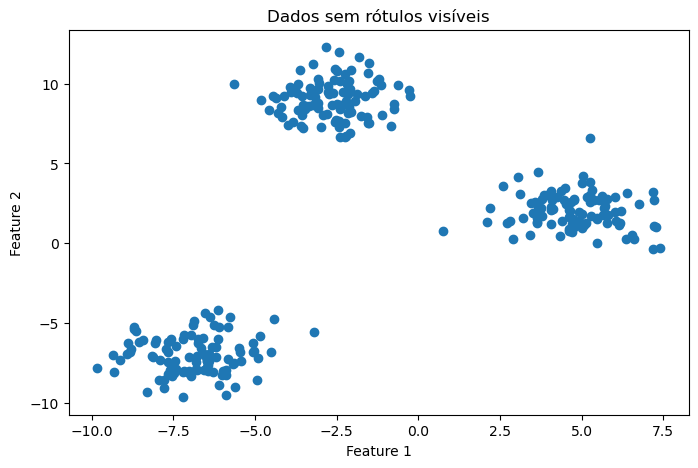

In [40]:
plt.scatter(X_cluster[:, 0], X_cluster[:, 1])
plt.title("Dados sem rótulos visíveis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 20. Padronizando os dados para clustering

Como K-Means usa distância, é recomendável escalar os dados.

In [44]:
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

print("Silhouette Score:", round(silhouette_score(X_cluster_scaled, cluster_labels), 4))

Silhouette Score: 0.8182


C:\Users\hjmou\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


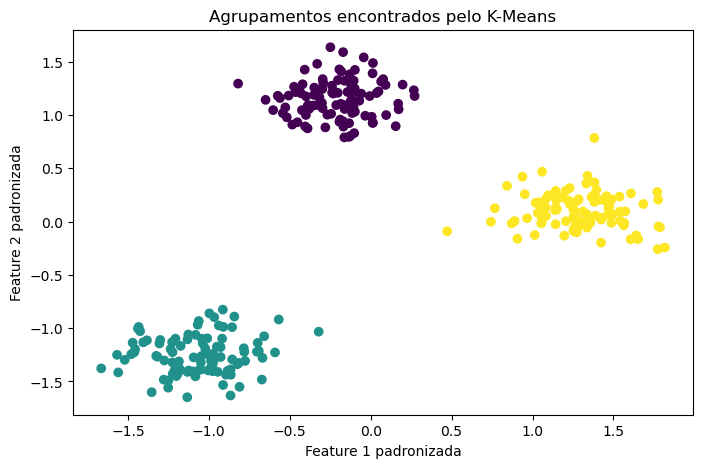

In [45]:
plt.scatter(X_cluster_scaled[:, 0], X_cluster_scaled[:, 1], c=cluster_labels)
plt.title("Agrupamentos encontrados pelo K-Means")
plt.xlabel("Feature 1 padronizada")
plt.ylabel("Feature 2 padronizada")
plt.show()

## 21. Interpretação do clustering

### O que o algoritmo fez?
Separou os exemplos em grupos com base em proximidade.

### Como avaliar?
Como não há alvo real em muitos cenários, usamos métricas internas, como:
- Silhouette Score
- inércia do K-Means

### Quando usar clustering?
Quando queremos explorar a estrutura dos dados sem rótulos.

# Parte IV — Comparando regressão, classificação e agrupamento

## 22. Comparação geral

In [46]:
comparacao = pd.DataFrame({
    "Aspecto": [
        "Tipo de aprendizado",
        "Saída",
        "Objetivo",
        "Exemplo de pergunta",
        "Métricas comuns",
        "Exemplos de algoritmos"
    ],
    "Regressão": [
        "Supervisionado",
        "Numérica contínua",
        "Prever valores",
        "Quanto?",
        "MAE, MSE, RMSE, R²",
        "Regressão Linear, Árvores"
    ],
    "Classificação": [
        "Supervisionado",
        "Categórica",
        "Prever classes",
        "Qual classe?",
        "Acurácia, Precisão, Recall, F1",
        "Árvore, KNN, SVM, Logística"
    ],
    "Agrupamento": [
        "Não supervisionado",
        "Grupos",
        "Descobrir padrões",
        "Quem é parecido com quem?",
        "Silhouette, Inércia",
        "K-Means, DBSCAN, Hierárquico"
    ]
})

comparacao

,Aspecto,Regressão,Classificação,Agrupamento
0,Tipo de aprendizado,Supervisionado,Supervisionado,Não supervisionado
1,Saída,Numérica contínua,Categórica,Grupos
2,Objetivo,Prever valores,Prever classes,Descobrir padrões
3,Exemplo de pergunta,Quanto?,Qual classe?,Quem é parecido com quem?
4,Métricas comuns,"MAE, MSE, RMSE, R²","Acurácia, Precisão, Recall, F1","Silhouette, Inércia"
5,Exemplos de algoritmos,"Regressão Linear, Árvores","Árvore, KNN, SVM, Logística","K-Means, DBSCAN, Hierárquico"


## 23. Resumo conceitual

### Regressão
- supervisionado
- saída contínua
- foco em previsão numérica

### Classificação
- supervisionado
- saída categórica
- foco em decidir rótulos

### Agrupamento
- não supervisionado
- sem alvo
- foco em descobrir estruturas ocultas

# Parte V — Pré-processamento: ligação com os modelos

## 24. Por que pré-processar?

O desempenho de modelos de ML depende fortemente da qualidade e da forma dos dados.

### Tarefas comuns de pré-processamento
- tratamento de valores ausentes;
- codificação de variáveis categóricas;
- normalização/padronização;
- tratamento de outliers;
- seleção de atributos.

## 25. Regras práticas por tipo de algoritmo

### Modelos baseados em distância
Exemplos:
- KNN
- SVM
- K-Means

**Boas práticas:**
- escalar dados;
- tratar outliers;
- codificar categóricos corretamente.

### Modelos lineares
Exemplos:
- Regressão Linear
- Regressão Logística

**Boas práticas:**
- padronizar;
- tratar outliers;
- usar one-hot encoding para variáveis nominais.

### Árvores e florestas
Exemplos:
- Decision Tree
- Random Forest

**Boas práticas:**
- não precisam de escala;
- geralmente são menos sensíveis a outliers;
- ainda exigem tratamento de nulos e categóricos.

## 26. Exemplo simples de one-hot encoding

Quando uma variável categórica **não tem ordem**, o ideal costuma ser usar **One-Hot Encoding**.

In [49]:
from sklearn.preprocessing import OneHotEncoder

df_cat = pd.DataFrame({
    "cor": ["azul", "verde", "vermelho", "azul"]
})

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df_cat[["cor"]])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["cor"]))
pd.concat([df_cat, encoded_df], axis=1)

,cor,cor_azul,cor_verde,cor_vermelho
0,azul,1.0,0.0,0.0
1,verde,0.0,1.0,0.0
2,vermelho,0.0,0.0,1.0
3,azul,1.0,0.0,0.0


## 27. Exemplo simples de padronização

A padronização transforma as variáveis para média 0 e desvio padrão 1.

In [50]:
from sklearn.preprocessing import StandardScaler

df_num = pd.DataFrame({
    "idade": [20, 25, 30, 35, 40],
    "salario": [2000, 3000, 5000, 8000, 12000]
})

scaler_demo = StandardScaler()
df_num_scaled = pd.DataFrame(
    scaler_demo.fit_transform(df_num),
    columns=df_num.columns
)

print("Dados originais:")
display(df_num)

print("\nDados padronizados:")
display(df_num_scaled)

Dados originais:


,idade,salario
0,20,2000
1,25,3000
2,30,5000
3,35,8000
4,40,12000



Dados padronizados:


,idade,salario
0,-1.414214,-1.100964
1,-0.707107,-0.825723
2,0.000000,-0.275241
3,0.707107,0.550482
4,1.414214,1.651446


# Parte VI — Exercícios de reflexão

## 28. Perguntas conceituais

1. Em que situação usar regressão em vez de classificação?
2. Por que K-Means é considerado aprendizado não supervisionado?
3. Por que alguns algoritmos precisam de escalonamento e outros não?
4. Qual a diferença entre `LabelEncoder` e `OneHotEncoder`?
5. Quando a métrica de acurácia pode ser insuficiente?